# Motif co-occurrence and peak composition analysis

Analyze which motifs co-occur in the same peaks — this reveals the combinatorial
TF logic driving chromatin accessibility in each cell type.

Analyses:
1. Per-cell-type peak × motif binary matrix → motif co-occurrence
2. Motif pair co-occurrence frequencies across cell types
3. Cell-type-specific vs shared co-occurrence patterns
4. Peak complexity (how many motifs per peak)

In [1]:
import os
import glob
import numpy as np
import pandas as pd
from itertools import combinations

import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [2]:
dataset = 'sc-islet-differentiation_10X-Multiome'
base_dir = f'/cellar/users/aklie/data/datasets/{dataset}'
results_dir = f'{base_dir}/results/3_single_task_models'

path_out = f'{results_dir}/motifs/gimme_cluster/syntax/cooccurrence'
os.makedirs(path_out, exist_ok=True)

# Cell type metadata
cell_type_meta = pd.read_csv(f'{base_dir}/config/cell_type_metadata.tsv', sep='\t')
color_dict = dict(zip(cell_type_meta['cell_type'], cell_type_meta['color']))
celltype_order = cell_type_meta['cell_type'].tolist()

# Motif annotations
initial_motifs = pd.read_csv(f'{results_dir}/motifs/gimme_cluster/tfs_initial.txt', sep='\t', header=None,
                              names=['cluster_name', 'annotation', 'evalue'])
annotation_dict = initial_motifs.set_index('cluster_name')['annotation'].to_dict()
annot_short = {k: v.split('_')[0] for k, v in annotation_dict.items()}

# Build peak × motif matrices per cell type

In [3]:
# For each cell type, build a binary peak × motif matrix
# (1 if motif has at least one hit in peak, 0 otherwise)
# Also track hit_coefficient_global per peak-motif pair (sum)

hit_files = sorted(glob.glob(f'{results_dir}/*/average/motifs/hits/counts_unified/hits.tsv'))
ct_list = []
peak_motif_binary = {}  # celltype -> (n_peaks, n_motifs) binary df
peak_complexity = {}  # celltype -> series of motifs-per-peak

for f in hit_files:
    ct = f.split('/')[-6]
    if ct not in color_dict:
        continue
    ct_list.append(ct)
    
    df = pd.read_csv(f, sep='\t', usecols=['peak_id', 'motif_name'])
    
    # Binary: does this peak contain this motif?
    binary = df.groupby(['peak_id', 'motif_name']).size().unstack(fill_value=0)
    binary = (binary > 0).astype(int)
    
    peak_motif_binary[ct] = binary
    peak_complexity[ct] = binary.sum(axis=1)
    
    print(f'{ct}: {binary.shape[0]} peaks, {binary.shape[1]} motifs, median {peak_complexity[ct].median():.0f} motifs/peak')
    del df

# Get union of all motif names
all_motifs = sorted(set().union(*[set(b.columns) for b in peak_motif_binary.values()]))
print(f'\n{len(all_motifs)} unique motifs across all cell types')

DE: 362701 peaks, 66 motifs, median 2 motifs/peak


ENP_phase1: 140110 peaks, 65 motifs, median 3 motifs/peak


FB_FLT1: 101395 peaks, 60 motifs, median 3 motifs/peak


PFG1: 228094 peaks, 67 motifs, median 3 motifs/peak


PFG2: 331818 peaks, 67 motifs, median 2 motifs/peak


...

late_SC_EC: 178744 peaks, 62 motifs, median 3 motifs/peak


late_SC_alpha: 154305 peaks, 60 motifs, median 2 motifs/peak


late_SC_beta: 189812 peaks, 63 motifs, median 3 motifs/peak


liver: 233876 peaks, 68 motifs, median 3 motifs/peak


proliferating_endocrine: 95437 peaks, 59 motifs, median 3 motifs/peak

70 unique motifs across all cell types


# Peak complexity: how many motifs per peak?

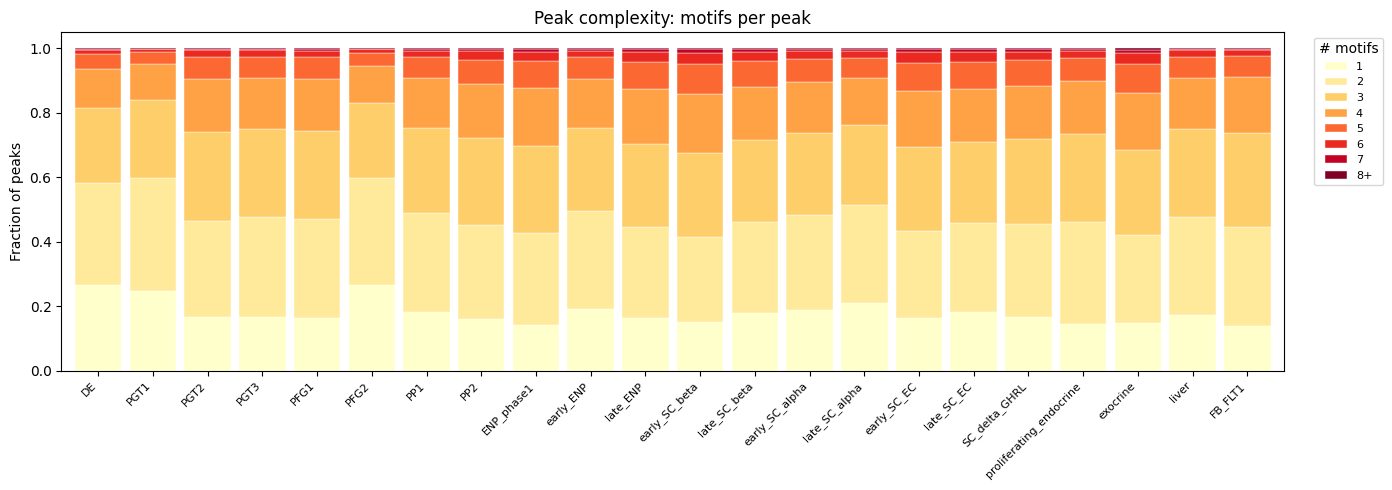

Mean motifs per peak:
  DE                             2.43
  PGT1                           2.38
  PGT2                           2.75
  PGT3                           2.73
  PFG1                           2.75
  PFG2                           2.38
  PP1                            2.70
  PP2                            2.83
  ENP_phase1                     2.91
  early_ENP                      2.69
  late_ENP                       2.87
  early_SC_beta                  2.97
  late_SC_beta                   2.81
  early_SC_alpha                 2.74
  late_SC_alpha                  2.64
  early_SC_EC                    2.90
  late_SC_EC                     2.83
  SC_delta_GHRL                  2.83
  proliferating_endocrine        2.80
  exocrine                       2.95
  liver                          2.72
  FB_FLT1                        2.79


In [4]:
# Distribution of motifs per peak — stacked barplot shows discrete distributions clearly
ct_plot = [ct for ct in celltype_order if ct in peak_complexity]

# Build proportion table: for each cell type, what fraction of peaks have 1,2,3,...N motifs
max_motifs = 8  # group 8+ together
prop_data = {}
for ct in ct_plot:
    counts = peak_complexity[ct].clip(upper=max_motifs).value_counts(normalize=True).sort_index()
    prop_data[ct] = counts

prop_df = pd.DataFrame(prop_data).T.fillna(0)
prop_df = prop_df.reindex(ct_plot)
prop_df.columns = [f"{int(c)}" if c < max_motifs else f"{max_motifs}+" for c in prop_df.columns]

# Stacked barplot
fig, ax = plt.subplots(figsize=(14, 5))
prop_df.plot.bar(stacked=True, ax=ax, colormap="YlOrRd", width=0.85, edgecolor="white", linewidth=0.3)
ax.set_ylabel("Fraction of peaks")
ax.set_title("Peak complexity: motifs per peak")
ax.legend(title="# motifs", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig(f"{path_out}/peak_complexity_stacked.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Also print means
print("Mean motifs per peak:")
for ct in ct_plot:
    print(f"  {ct:30s} {peak_complexity[ct].mean():.2f}")

# Motif co-occurrence matrices

For each cell type, compute pairwise co-occurrence: fraction of peaks containing motif A that also contain motif B.

In [5]:
# Compute co-occurrence for each cell type
# Jaccard similarity: |A ∩ B| / |A ∪ B| for each motif pair
# Use all motifs with >10 peaks (relaxed from >100)

cooccur_matrices = {}

for ct in ct_plot:
    binary = peak_motif_binary[ct].reindex(columns=all_motifs, fill_value=0)
    
    # Relaxed filter: >10 peaks
    motif_counts = binary.sum(axis=0)
    keep_motifs = motif_counts[motif_counts > 10].index.tolist()
    binary_filt = binary[keep_motifs]
    
    # Jaccard similarity
    n_motifs = len(keep_motifs)
    jaccard = pd.DataFrame(np.zeros((n_motifs, n_motifs)), index=keep_motifs, columns=keep_motifs)
    
    for i in range(n_motifs):
        for j in range(i, n_motifs):
            a = binary_filt.iloc[:, i].values
            b = binary_filt.iloc[:, j].values
            intersection = (a & b).sum()
            union = (a | b).sum()
            jac = intersection / union if union > 0 else 0
            jaccard.iloc[i, j] = jac
            jaccard.iloc[j, i] = jac
    
    cooccur_matrices[ct] = jaccard

print(f'Computed co-occurrence for {len(cooccur_matrices)} cell types')
# Show how many motifs pass filter per cell type
for ct in ct_plot[:5]:
    print(f'  {ct}: {len(cooccur_matrices[ct])} motifs')

Computed co-occurrence for 22 cell types
  DE: 65 motifs
  PGT1: 62 motifs
  PGT2: 63 motifs
  PGT3: 62 motifs
  PFG1: 62 motifs


Motifs in >=50% of cell types (>10 peaks each): 60 / 70


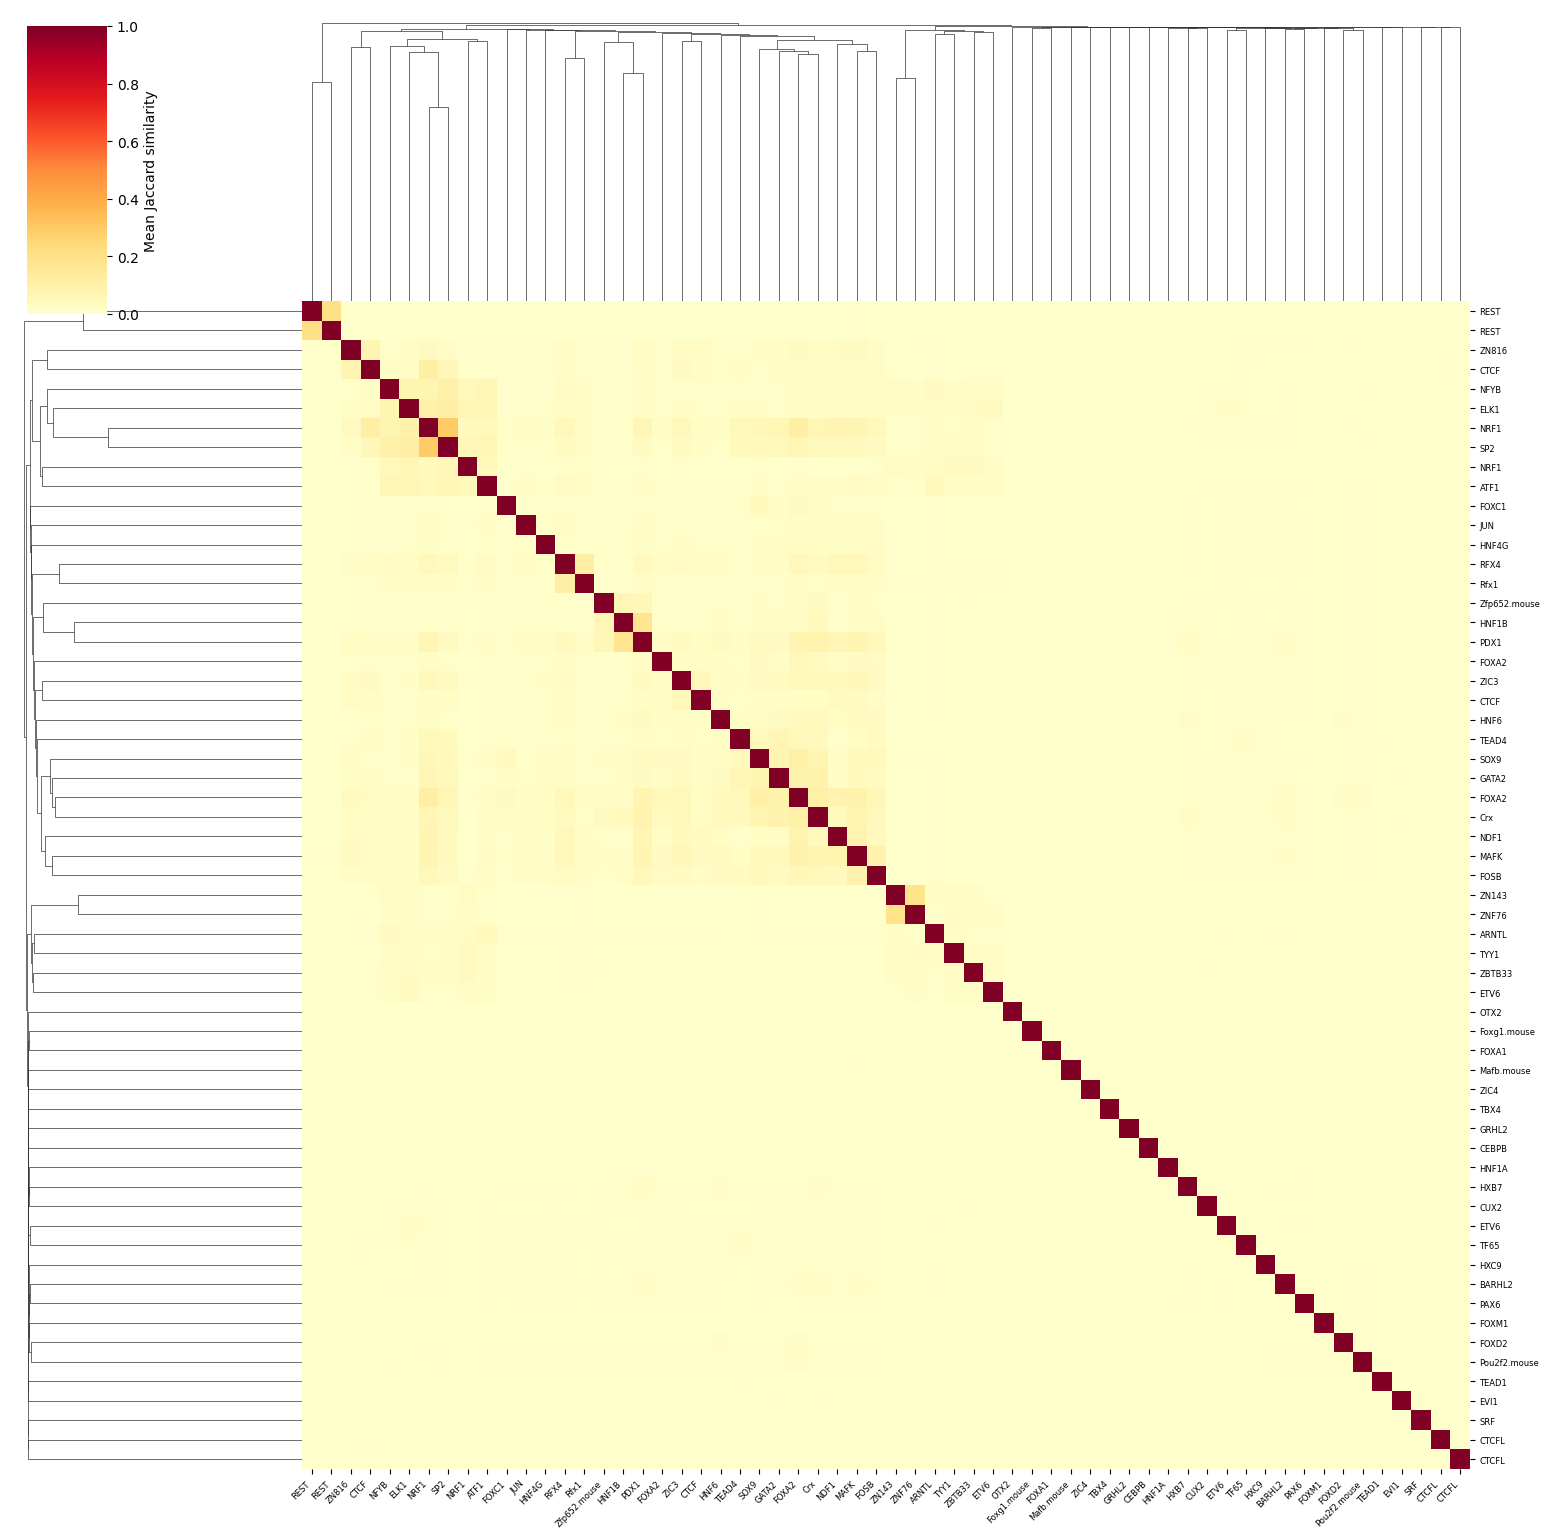

In [6]:
# Average co-occurrence across all cell types
# Use motifs present in >=50% of cell types (relaxed from 100%)
from collections import Counter

motif_presence = Counter()
for mat in cooccur_matrices.values():
    for m in mat.index:
        motif_presence[m] += 1

min_cts = len(cooccur_matrices) * 0.5  # present in at least half
common_motifs = sorted([m for m, c in motif_presence.items() if c >= min_cts])
print(f'Motifs in >=50% of cell types (>10 peaks each): {len(common_motifs)} / {len(all_motifs)}')

avg_cooccur = pd.DataFrame(np.zeros((len(common_motifs), len(common_motifs))),
                           index=common_motifs, columns=common_motifs)
ct_count = pd.DataFrame(np.zeros((len(common_motifs), len(common_motifs))),
                        index=common_motifs, columns=common_motifs)

for ct, mat in cooccur_matrices.items():
    shared = [m for m in common_motifs if m in mat.index]
    avg_cooccur.loc[shared, shared] += mat.loc[shared, shared]
    ct_count.loc[shared, shared] += 1

# Average only over cell types that had both motifs
avg_cooccur = avg_cooccur / ct_count.clip(lower=1)

# Rename to annotations
labels = [annot_short.get(m, m) for m in common_motifs]

# Clustermap
g = sns.clustermap(
    avg_cooccur.values,
    cmap='YlOrRd',
    figsize=(16, 16),
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={'label': 'Mean Jaccard similarity'},
)
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), fontsize=6, rotation=45, ha='right')
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), fontsize=6)
plt.savefig(f'{path_out}/avg_cooccurrence_clustermap.pdf', dpi=300, bbox_inches='tight')
plt.show()

# Cell-type-specific co-occurrence

Which motif pairs have co-occurrence patterns that differ across cell types?

In [7]:
# For each motif pair, compute the variance of Jaccard across cell types
# High variance = cell-type-specific co-occurrence

pair_data = []
for i, m1 in enumerate(common_motifs):
    for j, m2 in enumerate(common_motifs):
        if j <= i:
            continue
        vals = []
        for ct in cooccur_matrices:
            mat = cooccur_matrices[ct]
            if m1 in mat.index and m2 in mat.index:
                vals.append(mat.loc[m1, m2])
            else:
                vals.append(0.0)
        pair_data.append({
            'motif1': m1,
            'motif2': m2,
            'annotation1': annot_short.get(m1, m1),
            'annotation2': annot_short.get(m2, m2),
            'mean_jaccard': np.mean(vals),
            'std_jaccard': np.std(vals),
            'max_jaccard': np.max(vals),
            'cv': np.std(vals) / np.mean(vals) if np.mean(vals) > 0.01 else 0,
        })

pairs_df = pd.DataFrame(pair_data)
pairs_df = pairs_df.sort_values('std_jaccard', ascending=False)
pairs_df.to_csv(f'{path_out}/motif_pair_cooccurrence.csv', index=False)

print('Top variable motif pairs (cell-type-specific co-occurrence):')
for _, row in pairs_df.head(15).iterrows():
    print(f"  {row['annotation1']:12s} + {row['annotation2']:12s}  mean={row['mean_jaccard']:.3f}  std={row['std_jaccard']:.3f}  max={row['max_jaccard']:.3f}")

print(f'\nTop consistently co-occurring pairs (high mean, low variance):')
consistent = pairs_df[(pairs_df['mean_jaccard'] > 0.05) & (pairs_df['cv'] < 0.3)].sort_values('mean_jaccard', ascending=False)
for _, row in consistent.head(10).iterrows():
    print(f"  {row['annotation1']:12s} + {row['annotation2']:12s}  mean={row['mean_jaccard']:.3f}  cv={row['cv']:.2f}")

Top variable motif pairs (cell-type-specific co-occurrence):
  REST         + REST          mean=0.110  std=0.112  max=0.382
  GATA2        + Crx           mean=0.093  std=0.086  max=0.315
  HNF1B        + PDX1          mean=0.166  std=0.085  max=0.307
  FOXA2        + GATA2         mean=0.091  std=0.080  max=0.229
  MAFK         + NDF1          mean=0.089  std=0.077  max=0.222
  FOXA2        + NDF1          mean=0.084  std=0.072  max=0.205
  NRF1         + NDF1          mean=0.078  std=0.071  max=0.200
  NDF1         + PDX1          mean=0.068  std=0.068  max=0.216
  GATA2        + SOX9          mean=0.072  std=0.067  max=0.233
  GATA2        + TEAD4         mean=0.067  std=0.065  max=0.170
  MAFK         + PDX1          mean=0.077  std=0.064  max=0.214
  FOXA2        + SOX9          mean=0.104  std=0.057  max=0.227
  NRF1         + ELK1          mean=0.101  std=0.055  max=0.337
  NRF1         + GATA2         mean=0.067  std=0.054  max=0.148
  FOXA2        + TEAD4         mean=0.050  

Saved grid: 22 cell types, 60 motifs each


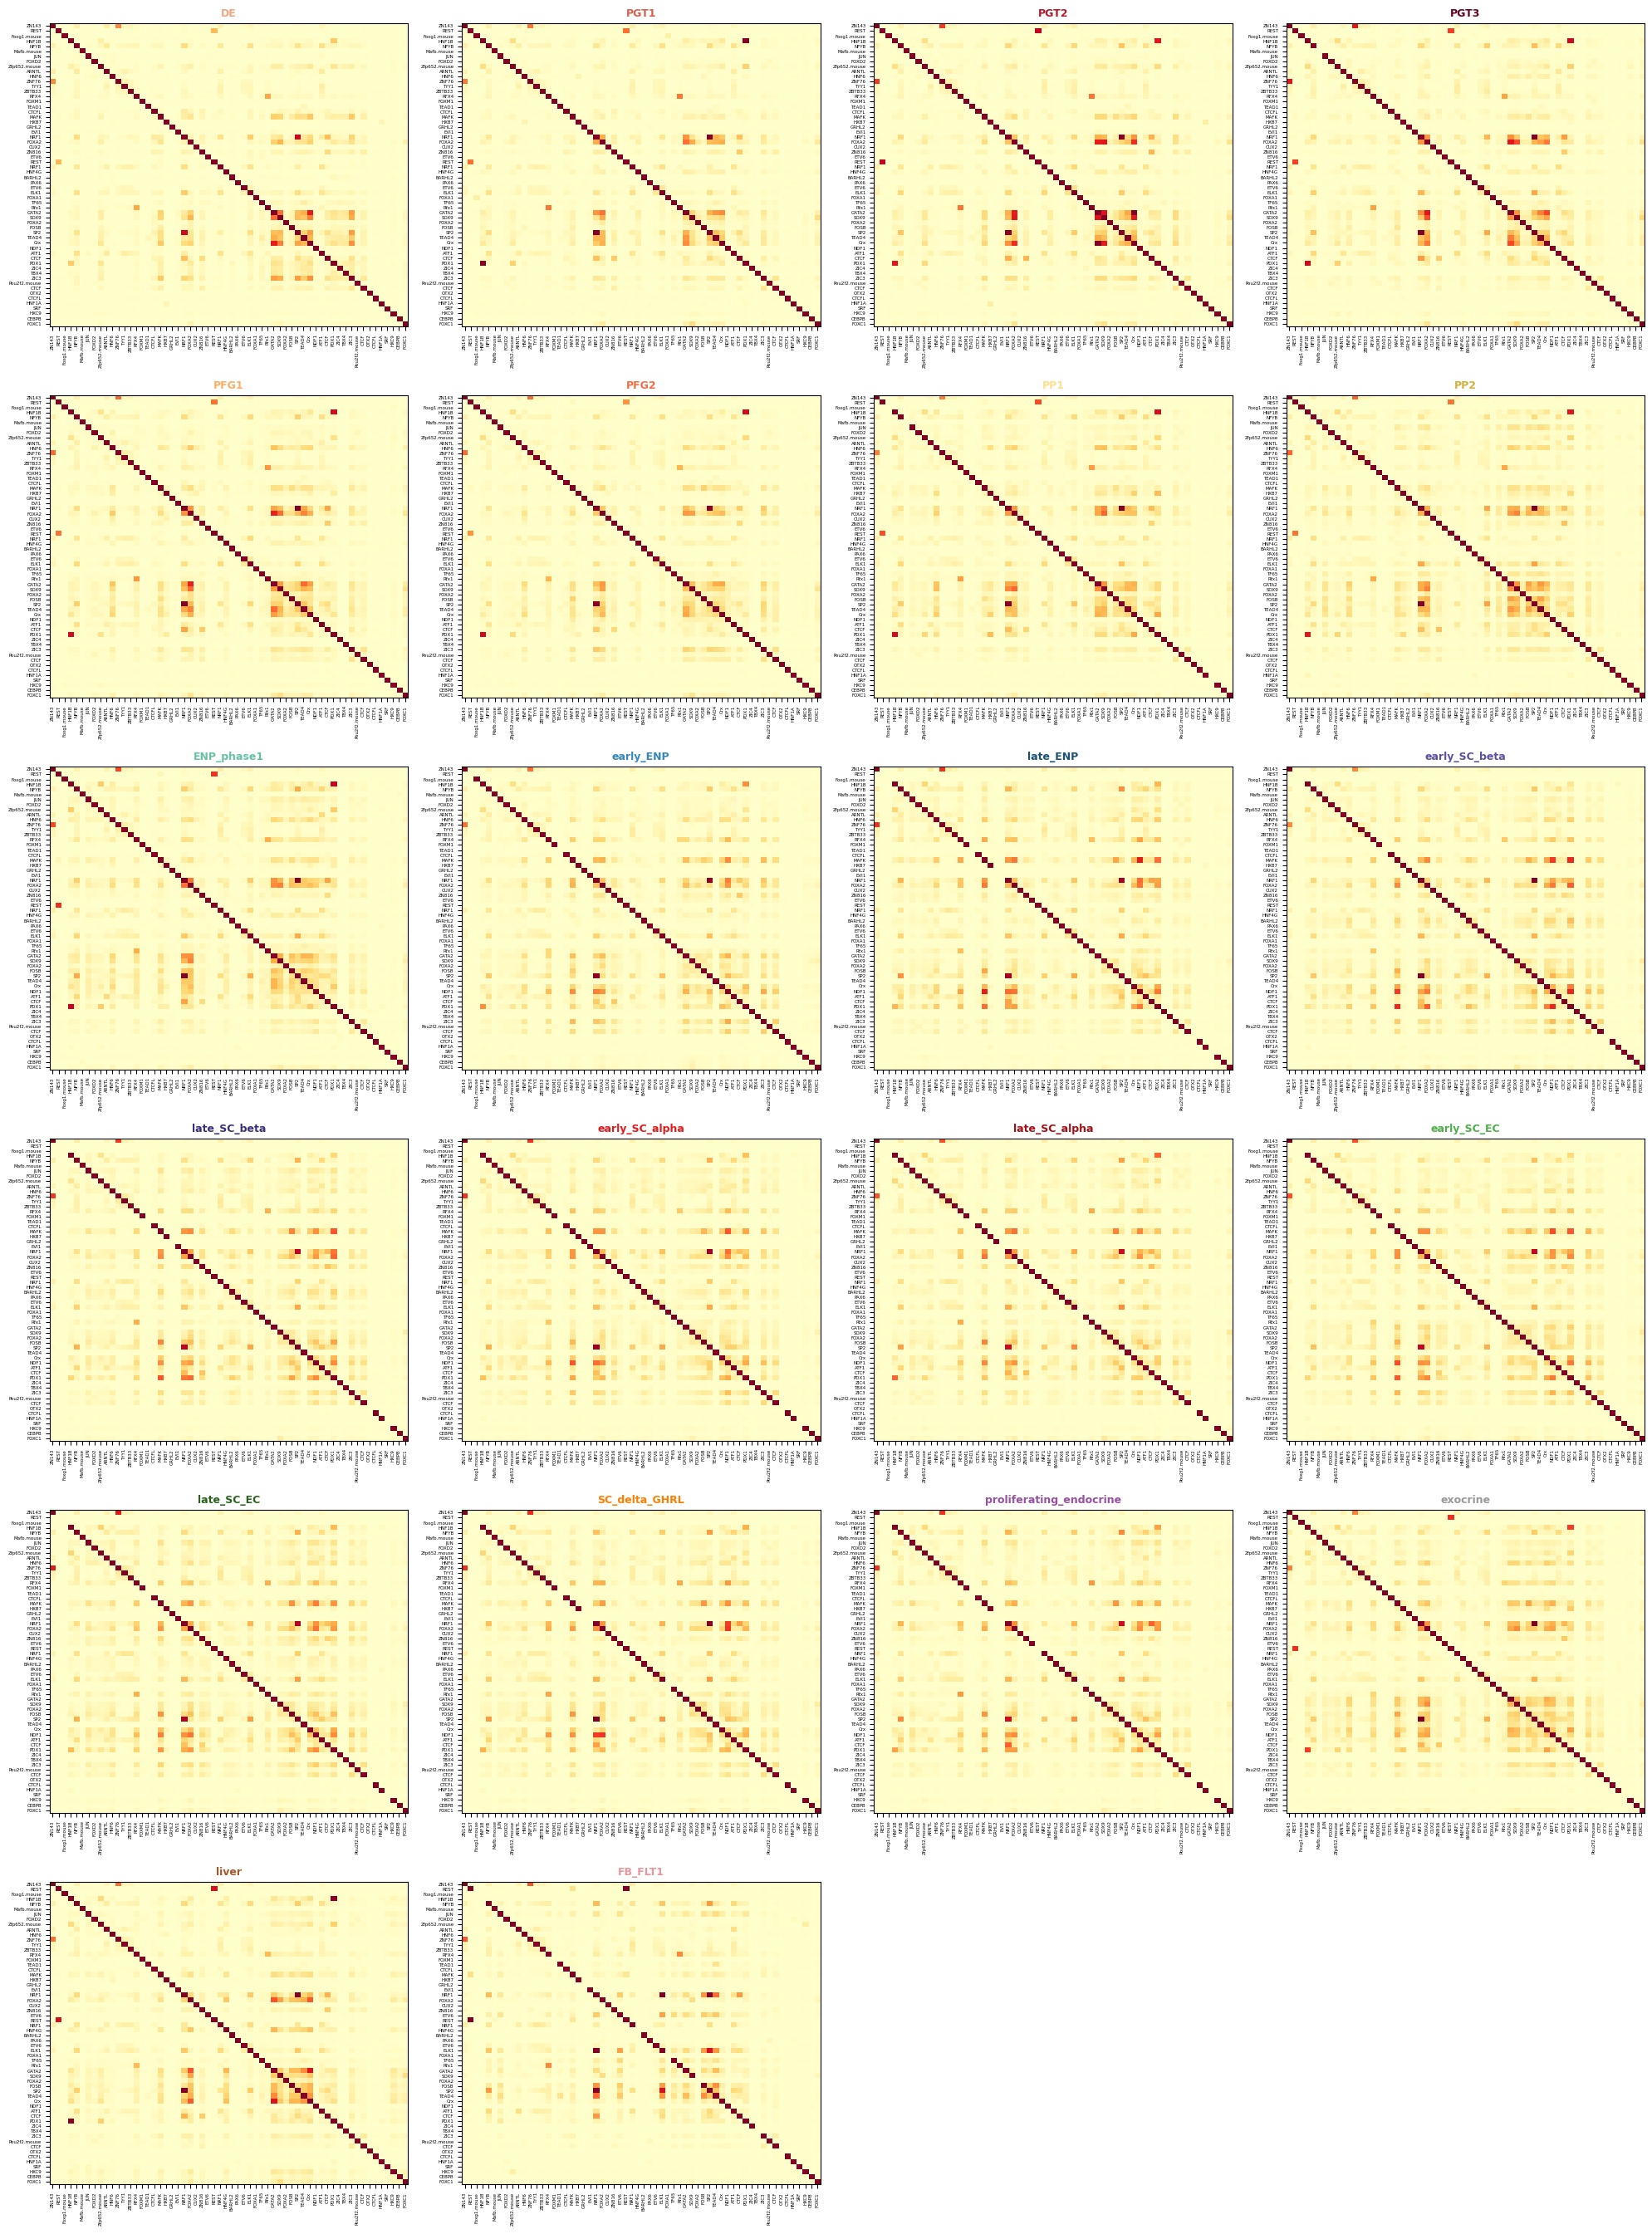

In [8]:
# All 22 cell types in a single grid
ct_plot_ordered = [ct for ct in celltype_order if ct in cooccur_matrices]
n_ct = len(ct_plot_ordered)
n_cols = 4
n_rows = (n_ct + n_cols - 1) // n_cols

labels = [annot_short.get(m, m) for m in common_motifs]

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 5, n_rows * 4.5))
axes = axes.flatten()

for idx, ct in enumerate(ct_plot_ordered):
    ax = axes[idx]
    # Reindex to common_motifs, filling missing with 0
    mat = cooccur_matrices[ct].reindex(index=common_motifs, columns=common_motifs, fill_value=0)
    im = ax.imshow(mat.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.3)
    ax.set_xticks(range(len(common_motifs)))
    ax.set_xticklabels(labels, fontsize=4, rotation=90)
    ax.set_yticks(range(len(common_motifs)))
    ax.set_yticklabels(labels, fontsize=4)
    ax.set_title(ct, fontsize=9, fontweight='bold', color=color_dict.get(ct, 'black'))

# Hide unused axes
for idx in range(n_ct, len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(f'{path_out}/cooccurrence_all_celltypes_grid.pdf', dpi=200, bbox_inches='tight')
print(f'Saved grid: {n_ct} cell types, {len(common_motifs)} motifs each')
plt.show()

In [9]:
# Per-cell-type individual exports
per_ct_dir = f'{path_out}/per_celltype'
os.makedirs(per_ct_dir, exist_ok=True)

for ct in ct_plot_ordered:
    mat = cooccur_matrices[ct].reindex(index=common_motifs, columns=common_motifs, fill_value=0)
    
    fig, ax = plt.subplots(figsize=(10, 9))
    im = ax.imshow(mat.values, cmap='YlOrRd', aspect='auto', vmin=0, vmax=0.3)
    ax.set_xticks(range(len(common_motifs)))
    ax.set_xticklabels(labels, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(len(common_motifs)))
    ax.set_yticklabels(labels, fontsize=7)
    ax.set_title(f'{ct} — motif co-occurrence (Jaccard)', fontsize=12,
                 fontweight='bold', color=color_dict.get(ct, 'black'))
    plt.colorbar(im, ax=ax, shrink=0.7, label='Jaccard similarity')
    plt.tight_layout()
    plt.savefig(f'{per_ct_dir}/{ct}_cooccurrence.pdf', dpi=150, bbox_inches='tight')
    plt.close(fig)

print(f'Saved {len(ct_plot_ordered)} per-cell-type PDFs to {per_ct_dir}')

Saved 22 per-cell-type PDFs to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/cooccurrence/per_celltype


# Save

In [10]:
avg_cooccur.to_csv(f'{path_out}/avg_cooccurrence_matrix.csv')
print(f'Saved to {path_out}')

Saved to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/3_single_task_models/motifs/cooccurrence


# DONE!